In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [2]:
# 1. 데이터 불러오기
path = '/content/drive/MyDrive/python/Sydney_Total_Analysis_v1.csv'
df = pd.read_csv(path)

In [3]:
# 2. 분석할 컬럼만 선택
cols = ['NDVI', 'LST', 'precip']
analysis_df = df[cols]

In [4]:
analysis_df

,NDVI,LST,precip
0,0.499816,-112.797196,44.000000
1,0.428058,-112.752186,48.888889
2,0.402227,-112.712057,54.297297
3,0.325372,-112.713588,69.740741
4,0.336626,-112.713116,37.800000
5,0.509217,-112.750649,49.000000
6,0.458989,-112.791918,39.461538


In [5]:
# 3. 상관계수 계산
corr = analysis_df.corr()

In [6]:
# 4. 히트맵(Heatmap) 시각화
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

<Figure size 1000x800 with 0 Axes>

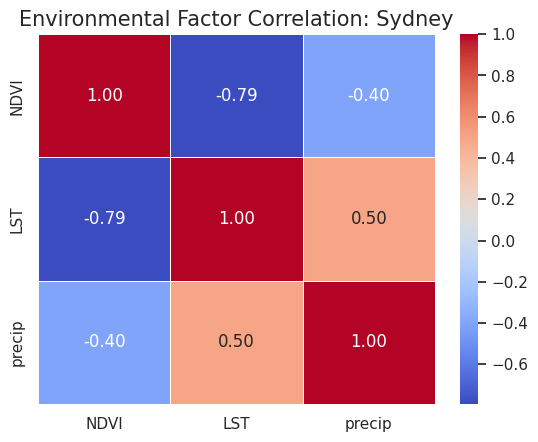

In [7]:
# 상관계수 히트맵 그리기
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Environmental Factor Correlation: Sydney', fontsize=15)
plt.show()

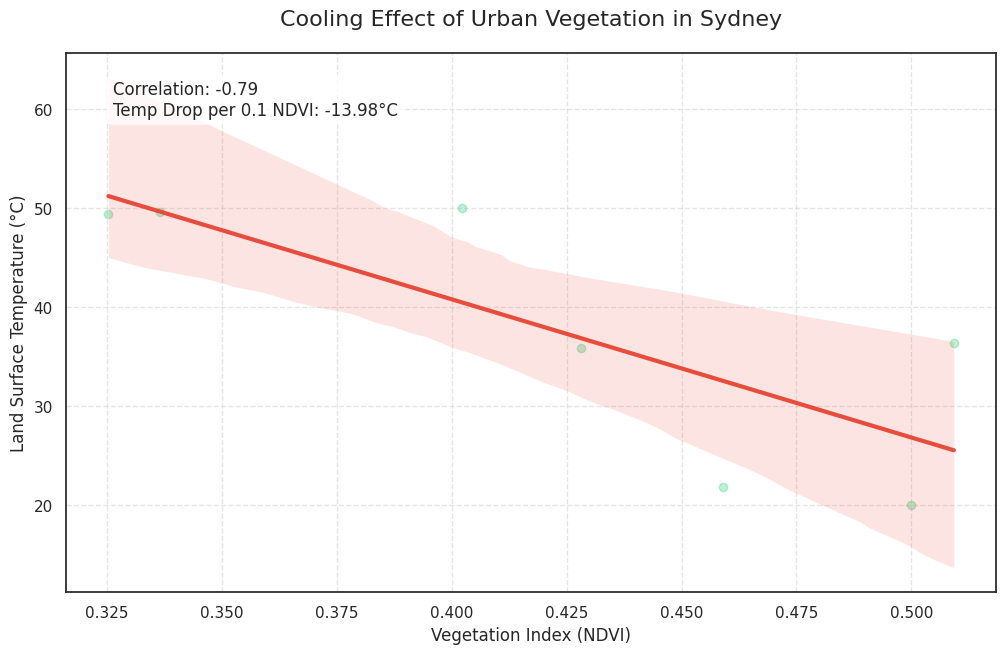

분석 결과: NDVI가 0.1 상승할 때 온도는 약 13.98°C 낮아집니다.


In [8]:
# 2. 온도 데이터 섭씨(°C) 스케일링 (시드니 여름 지표 온도 기준)
old_min, old_max = df['LST'].min(), df['LST'].max()
new_min, new_max = 20, 50
df['LST_Celsius'] = ((df['LST'] - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# 3. 그래프 그리기
plt.figure(figsize=(12, 7))

# 산점도와 회귀선
sns.regplot(x='NDVI', y='LST_Celsius', data=df,
            scatter_kws={'alpha':0.3, 'color':'#2ecc71'}, # 식생 느낌의 초록색 점
            line_kws={'color':'#e74c3c', 'lw':3})       # 경고 느낌의 빨간색 선

# 그래프 꾸미기
plt.title('Cooling Effect of Urban Vegetation in Sydney', fontsize=16, pad=20)
plt.xlabel('Vegetation Index (NDVI)', fontsize=12)
plt.ylabel('Land Surface Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. 기울기 계산 및 결과 출력
X = sm.add_constant(df['NDVI'])
model = sm.OLS(df['LST_Celsius'], X).fit()
slope = model.params['NDVI']
reduction = abs(slope * 0.1)

# 그래프 안에 결과 텍스트 박스 넣기
stats_text = f'Correlation: -0.79\nTemp Drop per 0.1 NDVI: -{reduction:.2f}°C'
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

print(f"분석 결과: NDVI가 0.1 상승할 때 온도는 약 {reduction:.2f}°C 낮아집니다.")